<a href="https://colab.research.google.com/github/Andrii-Panfilov-hub/IAD/blob/main/%D0%A0%D0%93%D0%A02_%D0%9F%D0%B0%D0%BD%D1%84%D1%96%D0%BB%D0%BE%D0%B2_%D0%9A%D0%9D_41.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Розрахунково-графічна робота 2**

з теорії ймовірностей, ймовірнісних процесів та математичної статистики

Панфілова Андрія Андрійовича КН-41

Варіант 16

# Первинний аналіз вибірки

Імпорт необхідних бібліотек для вирішення задач.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

Спочатку подамо вибірку у вигляді таблиці. Для первинного аналізу також побудуємо варіаційний ряд, тобто впорядкуємо всі елементи вибірки за зростанням. Варіаційний ряд має наступний вигляд: $x_1 \le x_2 \le \dots \le x_n$

In [6]:
data_array = np.array([
    0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 1, 0, 1, 0, 2, 0, 0, 0, 1, 0,
    0, 2, 4, 1, 1, 0, 1, 3, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
    1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 3, 0, 0, 0, 1, 0, 0, 1, 1, 1,
    1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0
])

data_df = pd.DataFrame({
    "Початкові дані": data_array.copy(),
    "Варіаційний ряд": sorted(data_array)
})

data_df

,Початкові дані,Варіаційний ряд
0,0,0
1,0,0
2,1,0
3,0,0
4,0,0
...,...,...
95,0,2
96,0,2
97,0,3
98,0,3


За побудованим варіаційним рядом можна зробити висновок, що вибірка має дискретний характер, оскільки її елементи набувають лише окремих числових значень. Далі визначимо об'єм вибірки $n$, найменше та найбільше значення вибірки, а також розмах.

$$
x_{(1)} = \min_{1 \le k \le n} x_k,
\qquad
x_{(n)} = \max_{1 \le k \le n} x_k,
\qquad
R = x_{(n)} - x_{(1)}.
$$

In [8]:
data_df_info = pd.DataFrame({
    "Об'єм вибірки": [len(data_array)],
    "Мінімальний елемент": [np.min(data_array)],
    "Максимальний елемент": [np.max(data_array)],
    "Розмах вибірки": [np.max(data_array) - np.min(data_array)]
})

data_df_info

,Об'єм вибірки,Мінімальний елемент,Максимальний елемент,Розмах вибірки
0,100,0,4,4


# Статистичний розподіл

Оскільки досліджувана вибірка має дискретний характер, для її подальшого аналізу побудуємо дискретний статистичний розподіл.

Нехай $x_1^*, x_2^*, \ldots, x_m^*$ — це різні значення вибірки, впорядковані за зростанням. Для кожного такого значення визначається частота його появи у вибірці.

Частотою $n_k$ називається кількість появ значення $x_k^*$ у вибірці. Сума всіх частот дорівнює обсягу вибірки:

$$
\sum_{k=1}^{m} n_k = n.
$$

Відносна частота $\nu_k$ показує, яку частину від усієї вибірки становить відповідне значення $x_k^*$:

$$
\nu_k = \frac{n_k}{n},
\qquad
\sum_{k=1}^{m} \nu_k = 1.
$$

Також для аналізу розподілу використовують накопичені частоти. Кумулятивна частота $n_k^*$ дорівнює сумі частот усіх значень, які не перевищують $x_k^*$:

$$
n_k^* = \sum_{i=1}^{k} n_i.
$$

Кумулятивна відносна частота $\nu_k^*$ визначається як сума відносних частот від першого значення до $k$-го:

$$
\nu_k^* = \sum_{i=1}^{k} \nu_i.
$$

На основі цих характеристик можна побудувати статистичний розподіл генеральної сукупності та емпіричну функцію розподілу.

Побудуємо статистичний розподіл для нашої реалізації.

In [9]:
freq = data_df['Варіаційний ряд'].value_counts(sort=False)
rel_freq = data_df['Варіаційний ряд'].value_counts(normalize=True, sort=False)

data_stat_dist_df = pd.DataFrame({
    "Значення": freq.index,
    "Частота": freq.values,
    "Відносна частота": rel_freq.values,
    "Кумулятивна частота": freq.cumsum().values,
    "Кумулятивна відносна частота": rel_freq.cumsum().values
})

data_stat_dist_df

,Значення,Частота,Відносна частота,Кумулятивна частота,Кумулятивна відносна частота
0,0,67,0.67,67,0.67
1,1,27,0.27,94,0.94
2,2,3,0.03,97,0.97
3,3,2,0.02,99,0.99
4,4,1,0.01,100,1.00


# Емпірична функція розподілу

**Емпірична функція розподілу**

Емпірична функція розподілу показує, яка частина елементів вибірки не перевищує заданого значення $x$. Для дискретного статистичного розподілу вона будується на основі накопичених відносних частот.

Емпірична функція розподілу має вигляд:

$$
F_n^*(x)=\frac{n_x}{n},
$$

де $n_x$ — кількість елементів вибірки, які не перевищують $x$, а $n$ — обсяг вибірки.

Загальна формула:
$$F_n^*(x) = \begin{cases}
0, & x \leq x_1^* \\
\nu_1^*, & x_1^* < x \leq x_2^* \\
\nu_2^*, & x_2^* < x \leq x_3^* \\
\dots & \dots \\
\nu_{m-1}^*, & x_{m-1}^* < x \leq x_m^* \\
1, & x > x_m^*
\end{cases}$$

Для заданої вибірки мого варіанта маємо такі значення емпіричної функції розподілу:

$$
F_n^*(x)=
\begin{cases}
0, & x < 0,\\
0.67, & 0 \le x < 1,\\
0.94, & 1 \le x < 2,\\
0.97, & 2 \le x < 3,\\
0.99, & 3 \le x < 4,\\
1, & x \ge 4.
\end{cases}
$$

Отже, емпірична функція розподілу є сходинковою функцією, оскільки вибірка має дискретний характер.

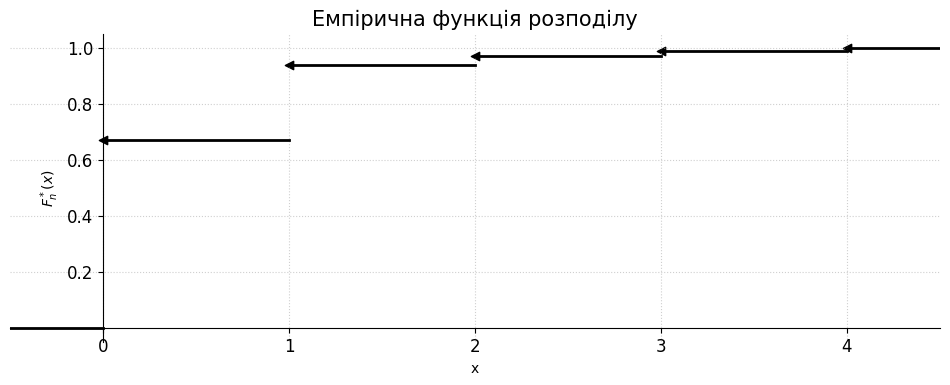

In [11]:
def plot_empirical_cdf(x_sample, y_sample):
    plt.plot(
        [x_sample[0] - 0.5, x_sample[0]],
        [0, 0],
        linewidth=2,
        color='black'
    )
    for i in range(len(x_sample) - 1):
        plt.plot(
            [x_sample[i], x_sample[i + 1]],
            [y_sample[i], y_sample[i]],
            linewidth=2,
            color='black'
        )
        plt.scatter(
            x_sample[i],
            y_sample[i],
            marker='<',
            color='black'
        )
    plt.plot(
        [x_sample[-1], x_sample[-1] + 0.5],
        [1, 1],
        linewidth=2,
        color='black'
    )
    plt.scatter(
        x_sample[-1],
        1,
        marker='<',
        color='black'
    )

fig, ax = plt.subplots(figsize=(12, 4))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.xaxis.set_tick_params(labelsize=12)
ax.yaxis.set_tick_params(labelsize=12)
x_vals = data_stat_dist_df['Значення'].values
y_vals = data_stat_dist_df['Кумулятивна відносна частота'].values
ax.set_xlim(x_vals.min() - 0.5, x_vals.max() + 0.5)
ax.set_ylim(-0.05, 1.05)
ax.set_xticks(x_vals)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1])
ax.set_title('Емпірична функція розподілу', fontsize=15)
ax.set_xlabel('x')
ax.set_ylabel('$F_n^*(x)$')
plot_empirical_cdf(x_vals, y_vals)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Полігон частот

**Полігон відносних частот**

Для наочного подання дискретного статистичного розподілу побудуємо полігон відносних частот. Він дозволяє побачити, як розподілені значення вибірки та які значення трапляються найчастіше.

Побудова полігону виконується так:

- на осі абсцис відкладаються різні значення вибірки $x_1^*, x_2^*, \ldots, x_m^*$;
- на осі ординат відкладаються відповідні відносні частоти $\nu_1, \nu_2, \ldots, \nu_m$;
- для кожного значення будується точка $M_k(x_k^*, \nu_k)$;
- отримані точки послідовно з’єднуються відрізками прямої.

Таким чином утворюється ламана лінія, яка і називається полігоном відносних частот.

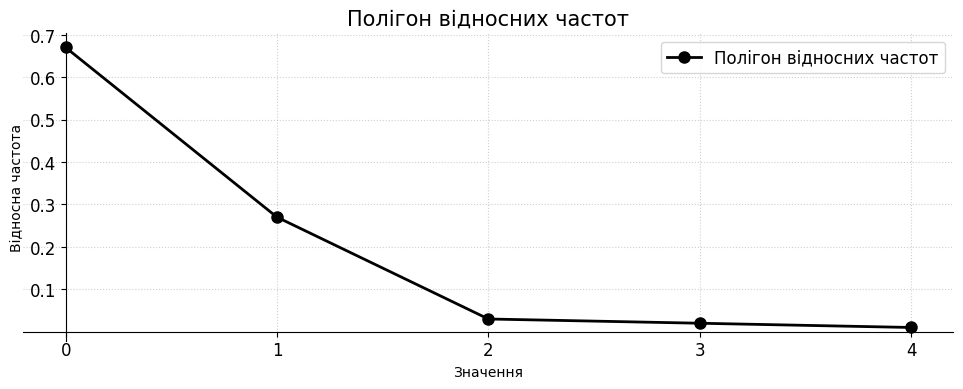

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.xaxis.set_tick_params(labelsize=12)
ax.yaxis.set_tick_params(labelsize=12)
ax.set_xticks(data_stat_dist_df['Значення'])
ax.set_yticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
ax.plot(
    data_stat_dist_df['Значення'],
    data_stat_dist_df['Відносна частота'],
    'o-',
    linewidth=2,
    markersize=8,
    color='black',
    label='Полігон відносних частот'
)
ax.set_title('Полігон відносних частот', fontsize=15)
ax.set_xlabel('Значення')
ax.set_ylabel('Відносна частота')
ax.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

З побудованого полігону відносних частот видно, що найбільшу частоту має значення 0, а зі збільшенням значень ознаки відносні частоти швидко зменшуються.

# Вибіркові характеристики генеральної сукупності
Нехай $x_1, \ldots, x_n$ - реалізація вибірки $\xi_1, \ldots, \xi_n$ з генеральної сукупності.

## Міри центральної тенденції

Для опису положення центру вибіркових даних використовують міри центральної тенденції: вибіркове середнє, медіану та моду.

Вибірковим середнім називають середнє арифметичне всіх елементів вибірки:

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i.
$$

Якщо розглядати вибірку як реалізацію випадкових величин $\xi_1, \xi_2, \ldots, \xi_n$, то вибіркове середнє можна записати так:

$$
\bar{\xi} = \frac{1}{n}\sum_{i=1}^{n}\xi_i.
$$

Вибіркове середнє добре характеризує центр розподілу, але воно може бути чутливим до дуже великих або дуже малих значень у вибірці. Тому додатково розглядають медіану та моду.

Нехай варіаційний ряд має вигляд:

$$
x_{(1)} \le x_{(2)} \le \ldots \le x_{(n)}.
$$

Вибірковою медіаною називають значення, яке ділить упорядковану вибірку на дві частини. Якщо кількість елементів непарна, медіаною є центральний елемент, а якщо парна — середнє арифметичне двох центральних елементів:

$$
Me^*\xi =
\begin{cases}
x_{(k+1)}, & n = 2k+1,\\
\dfrac{x_{(k)} + x_{(k+1)}}{2}, & n = 2k.
\end{cases}
$$

Вибірковою модою називають те значення вибірки, яке зустрічається найчастіше.

Ці характеристики дозволяють оцінити, біля яких значень зосереджена основна частина вибірки.

In [17]:
data_df_info['Вибіркове середнє'] = np.mean(data_df['Варіаційний ряд'])
data_df_info['Вибіркова медіана'] = np.median(data_df['Варіаційний ряд'])
data_df_info['Вибіркова мода'] = stats.mode(data_df['Варіаційний ряд'])[0]

data_df_info

,Об'єм вибірки,Мінімальний елемент,Максимальний елемент,Розмах вибірки,Вибіркове середнє,Вибіркова медіана,Вибіркова мода
0,100,0,4,4,0.43,0.0,0


Отримані характеристики показують, що основна частина елементів вибірки зосереджена поблизу нуля.

## Міри розсіювання вибірки

Міри розсіювання характеризують ступінь відхилення елементів вибірки від середнього значення. Найпростішою характеристикою розсіювання є розмах вибірки:

$$
R = x_{\max} - x_{\min}.
$$

Для досліджуваної вибірки:

$$
R = 4 - 0 = 4.
$$

Більш інформативною характеристикою є вибіркова дисперсія. Вона показує середній квадрат відхилення елементів вибірки від вибіркового середнього:

$$
D^* = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2.
$$

Оскільки вибіркова дисперсія є зміщеною оцінкою генеральної дисперсії, додатково обчислюють виправлену (незміщену) дисперсію:

$$
D^{**} = \frac{n}{n-1}D^*
=
\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2.
$$

Стандартне відхилення визначається як квадратний корінь із виправленої дисперсії:

$$
\sigma^* = \sqrt{D^{**}}.
$$

Ці характеристики дозволяють оцінити, наскільки сильно значення вибірки розсіюються відносно середнього значення.

In [18]:
data_df_info['Вибіркова дисперсія'] = np.var(data_df['Варіаційний ряд'])
data_df_info['Виправлена дисперсія'] = np.var(data_df['Варіаційний ряд'],ddof=1)
data_df_info['Стандартне відхилення'] = np.std(data_df['Варіаційний ряд'],ddof=1)
data_df_info

,Об'єм вибірки,Мінімальний елемент,Максимальний елемент,Розмах вибірки,Вибіркове середнє,Вибіркова медіана,Вибіркова мода,Вибіркова дисперсія,Виправлена дисперсія,Стандартне відхилення
0,100,0,4,4,0.43,0.0,0,0.5451,0.550606,0.742028


Отримані значення дисперсії та стандартного відхилення свідчать про невелике розсіювання елементів вибірки відносно середнього значення. Це пояснюється тим, що більшість спостережень зосереджені поблизу нуля, а великі значення зустрічаються рідко.

## Міри форми

Міри форми використовують для опису зовнішнього вигляду розподілу, зокрема його асиметрії та гостровершинності.

Спочатку введемо поняття вибіркового моменту $k$-го порядку:

$$
\mu_k^* = \frac{1}{n}\sum_{i=1}^{n}x_i^k.
$$

Також використовується вибірковий центральний момент $k$-го порядку:

$$
\mu_{k,0}^* = \frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^k.
$$

Зокрема, перший вибірковий момент дорівнює вибірковому середньому, а другий центральний момент відповідає вибірковій дисперсії.

Коефіцієнт асиметрії характеризує, наскільки розподіл відхиляється від симетричного вигляду:

$$
As^* = \frac{\mu_{3,0}^*}{(\sigma^*)^3}.
$$

Якщо $As^* \approx 0$, розподіл приблизно симетричний. Якщо $As^* > 0$, розподіл має правосторонню асиметрію. Якщо $As^* < 0$, розподіл має лівосторонню асиметрію.

Коефіцієнт ексцесу характеризує гостровершинність розподілу порівняно з нормальним розподілом:

$$
Ex^* = \frac{\mu_{4,0}^*}{(\sigma^*)^4} - 3.
$$

Якщо $Ex^* \approx 0$, розподіл близький до нормального за гостровершинністю. Якщо $Ex^* > 0$, розподіл є більш гостровершинним, а якщо $Ex^* < 0$ — більш плосковершинним.

In [19]:
data_df_info['Коефіцієнт асиметрії'] = stats.skew(data_df['Варіаційний ряд'],bias=False)
data_df_info['Коефіцієнт ексцесу'] = stats.kurtosis(data_df['Варіаційний ряд'],bias=False)
data_df_info

,Об'єм вибірки,Мінімальний елемент,Максимальний елемент,Розмах вибірки,Вибіркове середнє,Вибіркова медіана,Вибіркова мода,Вибіркова дисперсія,Виправлена дисперсія,Стандартне відхилення,Коефіцієнт асиметрії,Коефіцієнт ексцесу
0,100,0,4,4,0.43,0.0,0,0.5451,0.550606,0.742028,2.288942,6.572933


Отримане значення коефіцієнта асиметрії є додатним, тому розподіл має виражену правосторонню асиметрію. Це означає, що основна частина значень вибірки зосереджена поблизу нуля, тоді як більші значення трапляються значно рідше.

Коефіцієнт ексцесу є додатним і досить великим, що свідчить про високу гостровершинність розподілу. Отже, розподіл вибірки суттєво відрізняється від нормального та має концентровану область основних значень.

#Гіпотеза про розподіл генеральної сукупності

**Висунення гіпотези про розподіл генеральної сукупності**

За результатами первинного аналізу видно, що вибірка має дискретний характер, оскільки її значення є цілими невід’ємними числами: $0, 1, 2, 3, 4$. Для вибору теоретичної моделі порівняємо отримані вибіркові характеристики з властивостями основних дискретних розподілів: біноміального, геометричного та розподілу Пуассона.

Для біноміального розподілу $\mathrm{Bin}(N,p)$:

$$
P(\xi = k) = C_N^k p^k(1-p)^{N-k}, \qquad k = 0,1,\ldots,N.
$$

Математичне сподівання біноміального розподілу дорівнює:

$$
E\xi = Np.
$$

Оскільки найбільше значення у вибірці дорівнює $x_{\max}=4$, можна припустити, що $N=4$. Тоді точкова оцінка параметра $p$:

$$
p \approx \frac{\bar{x}}{N} = \frac{0.43}{4} = 0.1075.
$$

Для геометричного розподілу $\mathrm{Geom}^{(0)}(p)$:

$$
P(\xi = k) = p(1-p)^k, \qquad k = 0,1,2,\ldots.
$$

Його математичне сподівання має вигляд:

$$
E\xi = \frac{1-p}{p}.
$$

Тоді оцінка параметра $p$:

$$
p \approx \frac{1}{1+\bar{x}} = \frac{1}{1+0.43} \approx 0.6993.
$$

Для розподілу Пуассона $\mathrm{Poiss}(\lambda)$:

$$
P(\xi = k) = \frac{\lambda^k}{k!}e^{-\lambda}, \qquad k = 0,1,2,\ldots.
$$

Для цього розподілу математичне сподівання і дисперсія дорівнюють параметру $\lambda$:

$$
E\xi = D\xi = \lambda.
$$

Тому оцінка параметра:

$$
\lambda \approx \bar{x} = 0.43.
$$

Оскільки у вибірці найбільшу частоту має значення $0$, а частоти значень $1,2,3,4$ швидко зменшуються, розподіл має правосторонню асиметрію. Такий вигляд є характерним для розподілу Пуассона з малим параметром $\lambda$. Тому як початкову гіпотезу висунемо припущення, що генеральна сукупність має розподіл Пуассона:

$$
H_0: \xi \sim \mathrm{Poiss}(\lambda).
$$

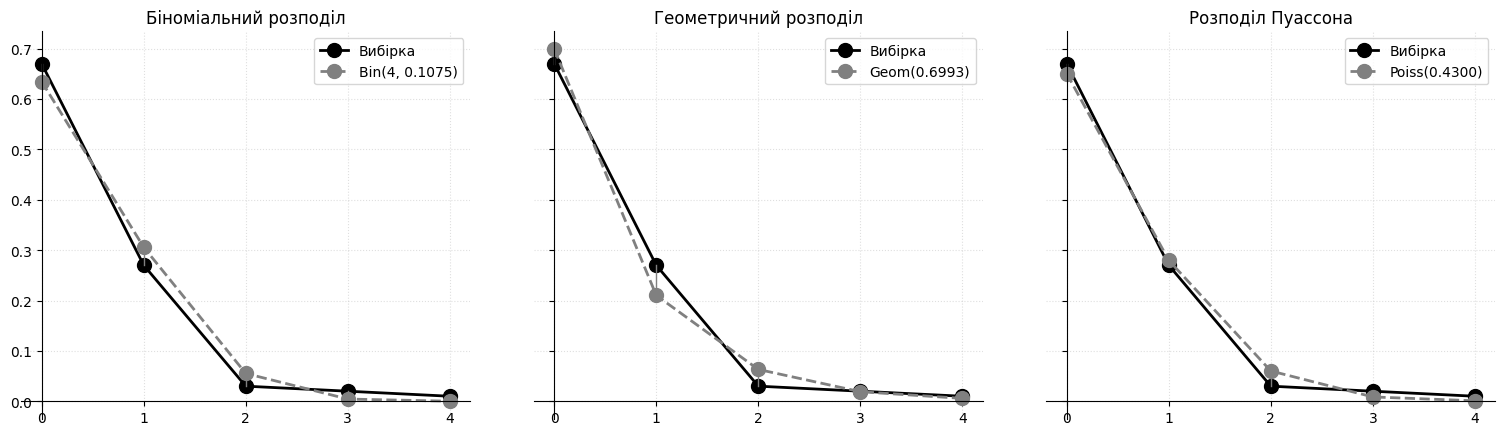

In [21]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16, 5), sharey=True)
fig.tight_layout(pad=3.0)
for i in range(3):
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['left'].set_position('zero')
    ax[i].spines['bottom'].set_position('zero')
x = data_stat_dist_df['Значення'].values
y_emp = data_stat_dist_df['Відносна частота'].values
mean_val = data_df_info['Вибіркове середнє'].iloc[0]
n_param = int(data_df_info['Максимальний елемент'].iloc[0])

# параметри розподілів
p_binom = mean_val / n_param
p_geom = 1 / (1 + mean_val)
lambda_poisson = mean_val

# теоретичні ймовірності
y0 = stats.binom.pmf(x, n_param, p_binom)
y1 = stats.geom.pmf(x + 1, p_geom)
y2 = stats.poisson.pmf(x, lambda_poisson)

# БІНОМІАЛЬНИЙ
ax[0].plot(
    x, y_emp,
    'o-',
    linewidth=2,
    markersize=10,
    color='black',
    label='Вибірка'
)

ax[0].plot(
    x, y0,
    'o--',
    linewidth=2,
    markersize=10,
    color='gray',
    label=f'Bin({n_param}, {p_binom:.4f})'
)

for xi, ye, yt in zip(x, y_emp, y0):
    ax[0].plot([xi, xi], [ye, yt], color='gray', linewidth=1)

ax[0].set_title('Біноміальний розподіл', fontsize=12)
ax[0].set_xticks(x)
ax[0].set_yticks(np.arange(0, 0.8, 0.1))
ax[0].grid(True, linestyle=':', alpha=0.4)
ax[0].legend(fontsize=10)

#ГЕОМЕТРИЧНИЙ
ax[1].plot(
    x, y_emp,
    'o-',
    linewidth=2,
    markersize=10,
    color='black',
    label='Вибірка'
)

ax[1].plot(
    x, y1,
    'o--',
    linewidth=2,
    markersize=10,
    color='gray',
    label=f'Geom({p_geom:.4f})'
)

for xi, ye, yt in zip(x, y_emp, y1):
    ax[1].plot([xi, xi], [ye, yt], color='gray', linewidth=1)

ax[1].set_title('Геометричний розподіл', fontsize=12)
ax[1].set_xticks(x)
ax[1].set_yticks(np.arange(0, 0.8, 0.1))
ax[1].grid(True, linestyle=':', alpha=0.4)
ax[1].legend(fontsize=10)

#ПУАССОН
ax[2].plot(
    x, y_emp,
    'o-',
    linewidth=2,
    markersize=10,
    color='black',
    label='Вибірка'
)

ax[2].plot(
    x, y2,
    'o--',
    linewidth=2,
    markersize=10,
    color='gray',
    label=f'Poiss({lambda_poisson:.4f})'
)
for xi, ye, yt in zip(x, y_emp, y2):
    ax[2].plot([xi, xi], [ye, yt], color='gray', linewidth=1)
ax[2].set_title('Розподіл Пуассона', fontsize=12)
ax[2].set_xticks(x)
ax[2].set_yticks(np.arange(0, 0.8, 0.1))
ax[2].grid(True, linestyle=':', alpha=0.4)
ax[2].legend(fontsize=10)

plt.show()

Порівняння полігону відносних частот із теоретичними розподілами показує, що найкраще експериментальні дані узгоджуються з розподілом Пуассона. Теоретичні ймовірності для розподілу Пуассона найближчі до емпіричних частот майже для всіх значень вибірки.

Отже, як основну гіпотезу обраємо припущення про те, що генеральна сукупність має розподіл Пуассона з параметром

$$
\lambda \approx 0.43.
$$

#Точкові оцінки параметрів розподілу

Оскільки як основну гіпотезу було висунуто припущення, що генеральна сукупність має розподіл Пуассона, тобто

$$
X \sim \mathrm{Poiss}(\lambda),
$$

потрібно знайти точкову оцінку невідомого параметра $\lambda$.

## Метод моментів

Метод моментів ґрунтується на прирівнюванні теоретичних моментів розподілу до відповідних вибіркових моментів. Для розподілу Пуассона математичне сподівання дорівнює параметру $\lambda$:

$$
E(X)=\lambda.
$$

Перший вибірковий момент — це вибіркове середнє $\bar{x}$. Тому прирівнюємо:

$$
\lambda = \bar{x}.
$$

Звідси оцінка параметра методом моментів:

$$
\hat{\lambda}_{MM} = \bar{x} = 0.43.
$$

## Метод максимальної вірогідності

Функція вірогідності для розподілу Пуассона має вигляд:

$$
L(\lambda)=\prod_{i=1}^{n}\frac{\lambda^{x_i}}{x_i!}e^{-\lambda}.
$$

Перейдемо до логарифмічної функції вірогідності:

$$
\ln L(\lambda)
=
\sum_{i=1}^{n}
\left(
x_i\ln\lambda-\lambda-\ln(x_i!)
\right).
$$

Знайдемо похідну за параметром $\lambda$ і прирівняємо її до нуля:

$$
\frac{d\ln L(\lambda)}{d\lambda}
=
\sum_{i=1}^{n}
\left(
\frac{x_i}{\lambda}-1
\right)
=0.
$$

Тоді:

$$
\frac{1}{\lambda}\sum_{i=1}^{n}x_i - n = 0.
$$

Звідси отримуємо:

$$
\hat{\lambda}_{ML}
=
\frac{1}{n}\sum_{i=1}^{n}x_i
=
\bar{x}.
$$

Отже, для розподілу Пуассона оцінки параметра, отримані методом моментів і методом максимальної вірогідності, збігаються:

$$
\hat{\lambda}_{MM}
=
\hat{\lambda}_{ML}
=
\bar{x}
=
0.43.
$$

#Властивості точкових оцінок

## Властивості точкової оцінки

Нехай $x_1, x_2, \ldots, x_n$ — реалізація вибірки з генеральної сукупності. На попередньому етапі було висунуто гіпотезу, що генеральна сукупність має розподіл Пуассона:

$$
X \sim \mathrm{Poiss}(\lambda).
$$

За методом моментів і методом максимальної вірогідності було отримано однакову оцінку параметра:

$$
\hat{\lambda}=\bar{x}=0.43.
$$

Перевіримо властивості цієї точкової оцінки.



## Незміщеність

Оцінка називається незміщеною, якщо її математичне сподівання дорівнює істинному значенню параметра:

$$
E(\hat{\lambda})=\lambda.
$$

Оскільки

$$
\hat{\lambda}=\bar{X}=\frac{1}{n}\sum_{i=1}^{n}X_i,
$$

то

$$
E(\hat{\lambda})
=
E(\bar{X})
=
\frac{1}{n}\sum_{i=1}^{n}E(X_i).
$$

Для розподілу Пуассона $E(X_i)=\lambda$, тому:

$$
E(\hat{\lambda})
=
\frac{1}{n}\cdot n\lambda
=
\lambda.
$$

Отже, оцінка $\hat{\lambda}=\bar{X}$ є незміщеною.



## Конзистентність

Оцінка називається конзистентною, якщо при збільшенні обсягу вибірки вона збігається за ймовірністю до істинного значення параметра.

За законом великих чисел вибіркове середнє збігається за ймовірністю до математичного сподівання:

$$
\bar{X} \xrightarrow{P} E(X).
$$

Оскільки для розподілу Пуассона

$$
E(X)=\lambda,
$$

то

$$
\hat{\lambda}=\bar{X}\xrightarrow{P}\lambda,
\qquad n\to\infty.
$$

Отже, оцінка $\hat{\lambda}$ є конзистентною.



## Ефективність

Оцінка називається ефективною, якщо вона має найменшу дисперсію серед усіх незміщених оцінок параметра.

Для оцінки

$$
\hat{\lambda}=\bar{X}
$$

дисперсія дорівнює:

$$
D(\hat{\lambda})
=
D(\bar{X})
=
\frac{D(X)}{n}.
$$

Для розподілу Пуассона

$$
D(X)=\lambda,
$$

тому

$$
D(\hat{\lambda})=\frac{\lambda}{n}.
$$

Інформація Фішера для одного спостереження розподілу Пуассона дорівнює:

$$
I(\lambda)=\frac{1}{\lambda}.
$$

Тоді нижня межа Рао-Крамера для $n$ незалежних спостережень:

$$
\frac{1}{nI(\lambda)}
=
\frac{1}{n\cdot \frac{1}{\lambda}}
=
\frac{\lambda}{n}.
$$

Оскільки

$$
D(\hat{\lambda})=\frac{\lambda}{n}
$$

збігається з нижньою межею Рао-Крамера, оцінка $\hat{\lambda}=\bar{X}$ є ефективною.


## Підсумок
Отже, для розподілу Пуассона оцінка параметра

$$
\hat{\lambda}=0.43
$$

є незміщеною, консистентною та ефективною.

# Побудова довірчого інтервалу

Знайдемо довірчий інтервал для невідомого параметра $\lambda$ розподілу Пуассона з рівнем довіри

$$
\gamma = 0.95.
$$

Оскільки для розподілу Пуассона

$$
E(X)=\lambda, \qquad D(X)=\lambda,
$$

то точкова оцінка параметра дорівнює вибірковому середньому:

$$
\hat{\lambda}=\bar{x}=0.43.
$$

Для великої вибірки використовуємо асимптотичний довірчий інтервал:

$$
\hat{\lambda} - t_\gamma \sqrt{\frac{\hat{\lambda}}{n}}
<
\lambda
<
\hat{\lambda} + t_\gamma \sqrt{\frac{\hat{\lambda}}{n}}.
$$

Для нашої вибірки маємо:

$$
n=100, \qquad \hat{\lambda}=0.43, \qquad \gamma=0.95.
$$

Для рівня довіри $0.95$ квантиль стандартного нормального розподілу:

$$
t_\gamma = 1.96.
$$

Знайдемо стандартну похибку:

$$
\sqrt{\frac{\hat{\lambda}}{n}}
=
\sqrt{\frac{0.43}{100}}
=
\sqrt{0.0043}
\approx 0.06557.
$$

Знайдемо величину відхилення:

$$
1.96 \cdot 0.06557 \approx 0.12852.
$$

Тоді нижня межа інтервалу:

$$
0.43 - 0.12852 = 0.30148.
$$

Верхня межа інтервалу:

$$
0.43 + 0.12852 = 0.55852.
$$

Отже, довірчий інтервал для параметра $\lambda$ при рівні довіри $0.95$ у вигляді нерівності має вигляд:

$$
0.30148 < \lambda < 0.55852.
$$

Або у вигляді інтервалу:

$$
\lambda \in (0.3015;\ 0.5585).
$$

Отже, з надійністю $0.95$ можна вважати, що значення параметра $\lambda$ розподілу Пуассона знаходиться в інтервалі від $0.3015$ до $0.5585$.

In [26]:
gamma = 0.95
# квантиль нормального розподілу
t_gamma = stats.norm.ppf(0.5 * (1 + gamma))
# обсяг вибірки
n = len(data_array)
# оцінка параметра lambda
lambda_est = data_df_info.iloc[0]['Вибіркове середнє']

# точний асимптотичний інтервал
lambda_1 = ( lambda_est+ t_gamma**2 / (2 * n)- t_gamma * (  lambda_est / n  + t_gamma**2 / (4 * n**2) )**0.5)
lambda_1 = np.around(lambda_1, 5)
lambda_2 = (lambda_est+ t_gamma**2 / (2 * n)+ t_gamma * (  lambda_est / n+ t_gamma**2 / (4 * n**2))**0.5)
lambda_2 = np.around(lambda_2, 5)

# спрощений інтервал
lambda_1_simplified = (lambda_est - t_gamma * (lambda_est / n)**0.5)
lambda_1_simplified = np.around(lambda_1_simplified, 5)
lambda_2_simplified = (lambda_est+ t_gamma * (lambda_est / n)**0.5)
lambda_2_simplified = np.around(lambda_2_simplified, 5)

print(f'Довірчий інтервал рівня {gamma} має вигляд 'f'({lambda_1}, {lambda_2})')
print(f'Спрощений довірчий інтервал рівня {gamma} має вигляд 'f'({lambda_1_simplified}, {lambda_2_simplified})')

Довірчий інтервал рівня 0.95 має вигляд (0.31926, 0.57916)
Спрощений довірчий інтервал рівня 0.95 має вигляд (0.30148, 0.55852)


# Перевірка гіпотези про закон розподілу генеральної сукупності

Перевіримо гіпотезу про те, що генеральна сукупність має розподіл Пуассона:

$$
H_0: \xi \sim \mathrm{Poiss}(\lambda), \qquad \lambda = 0.43.$$

Кількість параметрів, які оцінювалися за вибіркою, дорівнює

$$
s = 1.
$$

Для розподілу Пуассона теоретичні ймовірності обчислюються за формулою:

$$
P(\xi = k)=\frac{\lambda^k}{k!}e^{-\lambda}, \qquad k=0,1,2,\ldots
$$

Для нашої вибірки:

$$
n = 100, \qquad \lambda = 0.43.
$$

Теоретичні частоти знаходимо за формулою:

$$
E_k = n \cdot P(\xi = k).
$$

In [27]:
n = len(data_array)
lambda_est = data_df_info.iloc[0]['Вибіркове середнє']

df_chi2 = pd.DataFrame({
    'Класи': data_stat_dist_df['Значення'],
    'Частоти': data_stat_dist_df['Частота']
})

df_chi2['Теоретичні ймовірності'] = stats.poisson.pmf(
    df_chi2['Класи'],
    lambda_est
)

df_chi2['Теоретичні частоти'] = n * df_chi2['Теоретичні ймовірності']

df_chi2['O - E'] = df_chi2['Частоти'] - df_chi2['Теоретичні частоти']
df_chi2['(O - E)^2/E'] = df_chi2['O - E']**2 / df_chi2['Теоретичні частоти']

df_chi2

,Класи,Частоти,Теоретичні ймовірності,Теоретичні частоти,O - E,(O - E)^2/E
0,0,67,0.650509,65.050909,1.949091,0.058400
1,1,27,0.279719,27.971891,-0.971891,0.033769
2,2,3,0.060140,6.013957,-3.013957,1.510476
3,3,2,0.008620,0.862000,1.138000,1.502369
4,4,1,0.000927,0.092665,0.907335,8.884220


Оскільки теоретичні частоти для класів $3$ та $4$ менші за 5:

$$
E_3 = 0.862 < 5,
\qquad
E_4 = 0.093 < 5,
$$

то згідно з правилом використання критерію Пірсона об’єднаємо ці класи в один $\{3,4\}$.

In [28]:
classes = ['0', '1', '2', '3, 4']

freq_observed = np.array([ 67,27,3,2 + 1])
freq_expected = np.array([ 65.050909, 27.971891,6.013957,0.862000 + 0.092665])

df_chi2_mod = pd.DataFrame({
    'Класи': classes,
    'Частоти': freq_observed,
    'Теоретичні частоти': freq_expected
})

df_chi2_mod['O - E'] = (
    df_chi2_mod['Частоти']
    - df_chi2_mod['Теоретичні частоти']
)

df_chi2_mod['(O - E)^2/E'] = (
    df_chi2_mod['O - E']**2
    / df_chi2_mod['Теоретичні частоти']
)

df_chi2_mod

,Класи,Частоти,Теоретичні частоти,O - E,(O - E)^2/E
0,0,67,65.050909,1.949091,0.058400
1,1,27,27.971891,-0.971891,0.033769
2,2,3,6.013957,-3.013957,1.510476
3,"3, 4",3,0.954665,2.045335,4.382056


Після об’єднання класів 3,4 теоретична частота все одно менша за 5, тому приєднаємо ще другий клас.

In [29]:
classes = ['0', '1', '2, 3, 4']

freq_observed = np.array([ 67, 27, 3 + 2 + 1])
freq_expected = np.array([ 65.050909,27.971891,6.013957 + 0.862000 + 0.092665])

df_chi2_mod = pd.DataFrame({
    'Класи': classes,
    'Частоти': freq_observed,
    'Теоретичні частоти': freq_expected
})

df_chi2_mod['O - E'] = df_chi2_mod['Частоти'] - df_chi2_mod['Теоретичні частоти']
df_chi2_mod['(O - E)^2/E'] = df_chi2_mod['O - E']**2 / df_chi2_mod['Теоретичні частоти']

df_chi2_mod

,Класи,Частоти,Теоретичні частоти,O - E,(O - E)^2/E
0,0,67,65.050909,1.949091,0.058400
1,1,27,27.971891,-0.971891,0.033769
2,"2, 3, 4",6,6.968622,-0.968622,0.134636


In [32]:
chi2_emp = df_chi2_mod['(O - E)^2/E'].sum()
alpha = 0.05
m = len(df_chi2_mod)
s = 1
df = m - s - 1
chi2_crit = stats.chi2.ppf(1 - alpha, df)
print(f'χ² спостережувана статистика = {chi2_emp:.5f}')
print(f'χ² критичне = {chi2_crit:.5f}')
print(f'Ступені вільності = {df}')

χ² спостережувана статистика = 0.22680
χ² критичне = 3.84146
Ступені вільності = 1


Оскільки спостережуване значення статистики Пірсона є значно меншим за критичне значення

$\chi^2_{\text{спос}} = 0.2268$ < $\chi^2_{\text{кр}} = 3.84146$ для рівня значущості $\alpha = 0.05$ та відповідної кількості ступенів вільності $df = 1,$

Тому немає підстав відхиляти нашу гіпотезу. Отже, на рівні значущості $0.05$ можна вважати, що генеральна сукупність має розподіл Пуассона з параметром $$\lambda = 0.43$$

#ВИСНОВКИ

У ході виконання розрахунково-графічної роботи було проведено статистичний аналіз вибірки обсягом 100 елементів. Для вибірки побудовано варіаційний ряд, статистичний розподіл, емпіричну функцію розподілу та полігон відносних частот. Обчислено основні числові характеристики вибірки: вибіркове середнє, медіану, моду, дисперсію, стандартне відхилення, коефіцієнти асиметрії та ексцесу.

На основі аналізу вибірки було висунуто гіпотезу про те, що генеральна сукупність має розподіл Пуассона. Методом моментів і методом максимальної вірогідності отримано оцінку параметра:

$$
\hat{\lambda}=0.43.
$$

Для даного параметра було досліджено властивості точкової оцінки та показано, що вона є незміщеною, конзистентною та ефективною. Також побудовано довірчий інтервал для параметра $\lambda$ при рівні довіри $0.95$.

За допомогою критерію Пірсона виконано перевірку статистичної гіпотези. Оскільки спостережуване значення статистики критерію виявилось меншим за критичне, наша гіпотеза не була відхилена. Отже, результати дослідження підтверджують, що отримана вибірка узгоджується з розподілом Пуассона з параметром $\lambda = 0.43.$